<a href="https://colab.research.google.com/github/mouryasmouryas-dsp/ECG-Signal-Denoising-System/blob/main/02_Add_Noise_to_ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


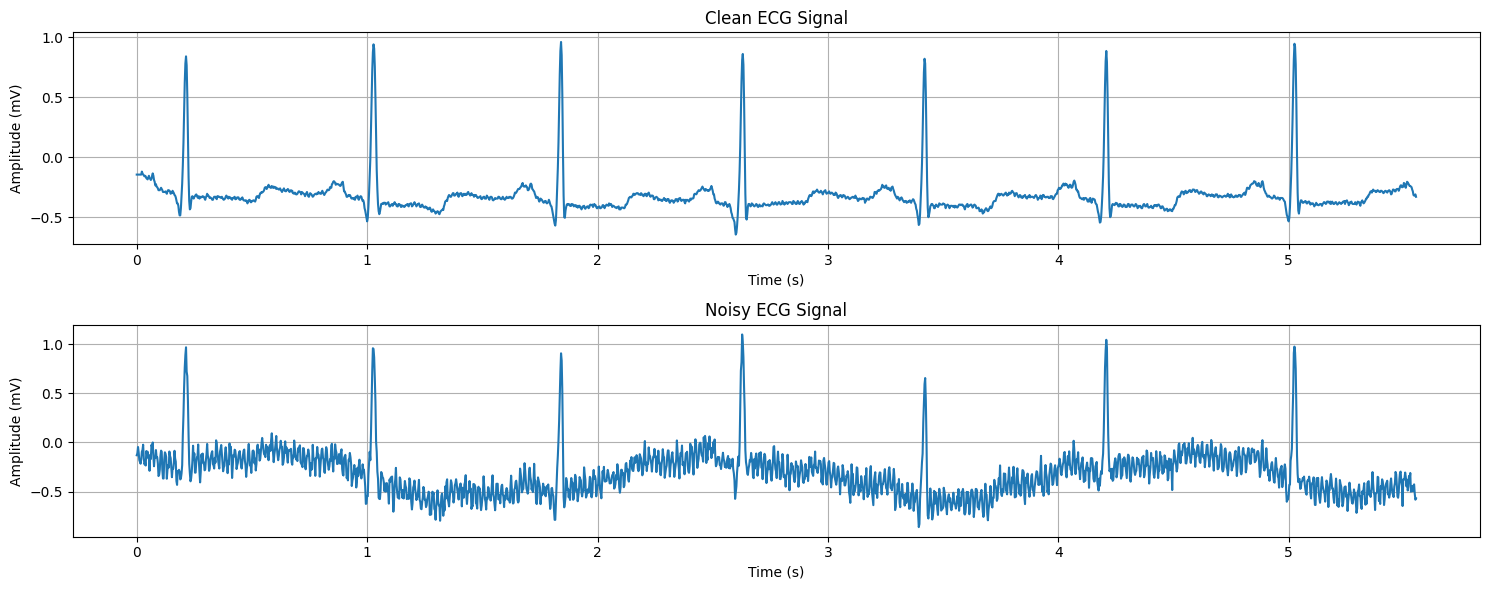

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Load ECG data
record = wfdb.rdrecord('100', pn_dir='mitdb')
ecg = record.p_signal[:, 0]
fs = record.fs

# Use first 2000 samples
samples = 2000
t = np.arange(samples) / fs
clean_ecg = ecg[:samples]

# 1. Power-line interference (50 Hz)
powerline_noise = 0.1 * np.sin(2 * np.pi * 50 * t)

# 2. Baseline wander (0.5 Hz)
baseline_wander = 0.2 * np.sin(2 * np.pi * 0.5 * t)

# 3. Muscle noise (random Gaussian noise)
muscle_noise = 0.05 * np.random.randn(samples)

# Total noise
total_noise = powerline_noise + baseline_wander + muscle_noise

# Noisy ECG
noisy_ecg = clean_ecg + total_noise

# Plot clean and noisy ECG
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(t, clean_ecg)
plt.title('Clean ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, noisy_ecg)
plt.title('Noisy ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)

plt.tight_layout()
plt.show()